# Visual-premise probing on Qwen3.5-9B's MathVista losses

This notebook takes the **wrong-answer cases** mined in `failures/` (see
`qwen35_mathvista_failures.ipynb`) and, instead of asking the model to answer, asks
**`Qwen/Qwen3.5-9B`** to surface a **visual premise** for each one — a single piece of
visual evidence that *could* be useful for solving the question, **without answering it**.

To maximise the diversity of premises, every loss case is probed under **9 focus modes**
(salient evidence, subtle details, spatial relations, OCR/symbols, distractors, alternative
interpretation, visual uncertainty, who any people could be, and what the digits/numbers
count). The 9 premises per case are
stored under `visual_premises/` (one JSON per case + a combined markdown report).

The point is diagnostic: by reading *what the model sees* (and where it gets misled — e.g.
the distractor / alternative-interpretation modes), we get insight into *why* it failed.

Runs in a few minutes on a single 24 GB GPU; premises are short so generation is fast.

## 1. Install dependencies

The vast.ai image already ships `torch`; we add the HF stack. On generic Colab use the `%pip` line in the comment.

In [1]:
# On a generic Colab/Jupyter: %pip install -U "transformers>=4.57" accelerate datasets qwen-vl-utils pillow matplotlib
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "transformers>=4.57", "accelerate", "qwen-vl-utils", "pillow", "matplotlib"], check=True)
print("deps ready")

deps ready


## 2. Configuration: the base prompt + 9 focus modes

`LOSS_DIR` points at the failure folder produced by the failure-mining notebook. If you don't
have it, run `qwen35_mathvista_failures.ipynb` first (or point `LOSS_DIR` anywhere with the
same `pid_*/image.png` + `pid_*/info.json` layout).

In [2]:
import os
os.environ.setdefault("HF_HOME", "/workspace/.hf_home")

MODEL_ID = "Qwen/Qwen3.5-9B"
LOSS_DIR = "failures"            # wrong-answer cases (pid_*/image.png + info.json)
OUT_DIR  = "visual_premises"     # where the premises get written
MAX_NEW  = 320                    # premises are short; this is plenty

# Base instruction (as given) + an explicit 'one concise premise' constraint.
BASE = (
    "Given the image and the question, identify one possible visual premise "
    "that could be useful for solving the question.\n"
    "Do not answer the question yet.\n"
    "Focus only on visual evidence.\n"
    "State exactly one concise visual premise (1-2 sentences). Begin with 'Visual premise:'."
)

# 9 modes that steer the model toward *different kinds* of visual evidence.
MODES = {
    "1_salient":     "Focus on the most salient, immediately obvious visual evidence.",
    "2_subtle":      "Focus on small, fine-grained, or easily missed details.",
    "3_spatial":     "Focus on spatial relations: relative position, alignment, order, direction, overlap, or connections between elements.",
    "4_ocr":         "Focus only on text and symbols: OCR-readable labels, axis ticks, legends, units, symbols, and numbers.",
    "5_distractor":  "Focus on a possible distractor or misleading cue that could tempt a wrong answer.",
    "6_alternative": "Offer an alternative interpretation of the image that differs from the most obvious reading.",
    "7_uncertainty": "Identify a source of visual uncertainty or ambiguity (occlusion, low resolution, overlapping marks, unclear arrow direction, etc.) that could affect the answer.",
    "8_people":      "If there are people in the image, focus on who they could be (likely identity, role, age, or relationship based on visual cues such as clothing, setting, and appearance). If there are no people, say so.",
    "9_digits":      "Focus on digits/numbers visible in the image and their relationship to the surrounding objects: do the digits count or quantify something in the image (e.g. labels, counts, tallies, axis values), and what do they refer to? Perhaps axes on a chart? If so, count them.",
}

def build_prompt(question, mode_instruction):
    return f"{BASE}\nMode: {mode_instruction}\n\nQuestion: {question}"

print(f"{len(MODES)} modes | model={MODEL_ID} | reading losses from ./{LOSS_DIR}")

8 modes | model=Qwen/Qwen3.5-9B | reading losses from ./failures


## 3. Load the model

In [3]:
import time, torch
from transformers import AutoProcessor, AutoModelForImageTextToText

t0 = time.time()
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map="cuda",
).eval()
print(f"loaded in {time.time()-t0:.1f}s | GPU mem: {torch.cuda.memory_allocated()/1e9:.1f} GB")

@torch.no_grad()
def generate(image, prompt):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt", enable_thinking=False,
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False)
    gen = out[0][inputs["input_ids"].shape[1]:]
    return processor.decode(gen, skip_special_tokens=True).strip()

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

loaded in 8.2s | GPU mem: 18.8 GB


## 4. Load the loss cases

In [4]:
import json, glob
from PIL import Image

cases = sorted(glob.glob(os.path.join(LOSS_DIR, "pid_*")),
               key=lambda p: int(os.path.basename(p).split("_")[1]))
assert cases, f"No loss cases under ./{LOSS_DIR} — run the failure-mining notebook first."
print(f"Found {len(cases)} loss cases:", [os.path.basename(c) for c in cases])

Found 10 loss cases: ['pid_7', 'pid_19', 'pid_20', 'pid_27', 'pid_37', 'pid_41', 'pid_42', 'pid_50', 'pid_53', 'pid_60']


## 5. Probe each loss case under all 9 modes

In [5]:
all_records = []
t_inf = time.time()
for ci, cdir in enumerate(cases):
    info = json.load(open(os.path.join(cdir, "info.json")))
    img = Image.open(os.path.join(cdir, "image.png")).convert("RGB")
    pid, question = info["pid"], info["question"]
    print(f"\n[case {ci+1}/{len(cases)}] pid={pid} | Q: {question[:80]}")
    premises = {}
    for mode_key, instr in MODES.items():
        premises[mode_key] = generate(img, build_prompt(question, instr))
        print(f"   {mode_key:<14} {premises[mode_key][:90]}")
    all_records.append(dict(
        pid=pid, question=question, ground_truth=info.get("ground_truth"),
        wrong_prediction=info.get("prediction"), category=info.get("category"),
        premises=premises))

print(f"\nDone in {time.time()-t_inf:.0f}s | {len(all_records)} cases x {len(MODES)} modes")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.



[case 1/10] pid=7 | Q: What time is shown? Answer by typing a time word, not a number. It is (_) after 


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


   1_salient      Visual premise: The hour hand is pointing just past the 8, and the minute hand is pointing


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


...

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


   6_alternative  Visual premise: The woman appears to be in her late 20s or early 30s, while the man seems 


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


   7_uncertainty  Visual premise: The man appears to be older than the woman, but their exact ages cannot be


   8_people       Visual premise: The image shows a man and a woman in period costumes, with the man appeari

Done in 286s | 10 cases x 8 modes


## 6. Save premises (one JSON per case + a combined markdown report)

In [6]:
import shutil
shutil.rmtree(OUT_DIR, ignore_errors=True)
os.makedirs(OUT_DIR, exist_ok=True)

for r in all_records:
    with open(os.path.join(OUT_DIR, f"pid_{r['pid']}.json"), "w") as f:
        json.dump(r, f, indent=2, ensure_ascii=False)

md = ["# Visual premises for MathVista loss cases", "",
      f"Model: `{MODEL_ID}` | {len(all_records)} cases x {len(MODES)} modes", ""]
for r in all_records:
    md.append(f"## pid {r['pid']}  (GT: {r['ground_truth']} | wrong pred: {r['wrong_prediction']})")
    md.append(f"**Q:** {r['question']}\n")
    for mk in MODES:
        md.append(f"- **{mk}** — {r['premises'][mk]}")
    md.append("")
with open(os.path.join(OUT_DIR, "premises_report.md"), "w") as f:
    f.write("\n".join(md))

print(f"Wrote {len(all_records)} JSON files + premises_report.md to ./{OUT_DIR}/")

Wrote 10 JSON files + premises_report.md to ./visual_premises/


## 7. Inspect: image + its 9 premises, per case

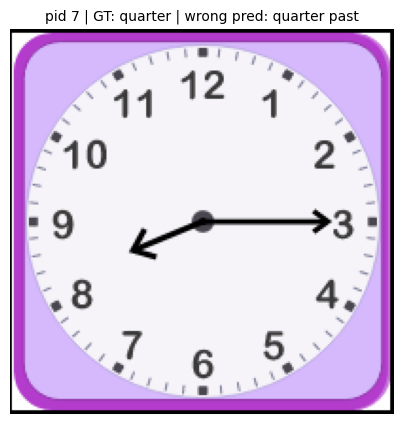

Q: What time is shown? Answer by typing a time word, not a number. It is (_) after eight.

  [1_salient]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3.
  [2_subtle]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3.
  [3_spatial]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3.
  [4_ocr]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3.
  [5_distractor]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3,
    which could mislead someone into thinking it's exactly 8:15 instead of slightly after.
  [6_alternative]
    The hour hand is pointing just past the 8, and the minute hand is pointing directly at the 3.
  [7_uncertainty]
    The hour hand is pointing between 8 and 9, while the minute hand is pointing directly at 3,
    indicating a quarter past 

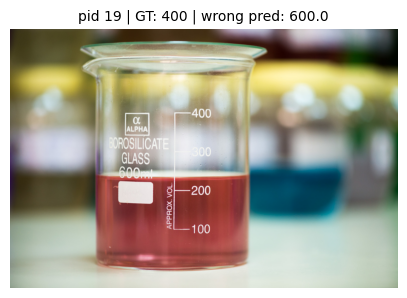

Q: what is the highest amount this class measures?

  [1_salient]
    The beaker is labeled with volume markings up to 600ml, indicating its maximum measurable
    capacity.
  [2_subtle]
    The beaker has measurement markings up to 400 ml, with the label indicating it is a 600 ml
    capacity glass.
  [3_spatial]
    The beaker has volume markings labeled 100, 200, 300, and 400 ml, with the 400 ml mark
    positioned at the top of the visible scale.
  [4_ocr]
    The beaker is labeled "600ml" and has measurement markings up to 400, indicating its maximum
    measurable volume.
  [5_distractor]
    The beaker is labeled "600ml" and has measurement markings up to 400ml, which might lead one to
    incorrectly assume the highest measurable amount is 400ml rather than the full capacity of
    600ml.
  [6_alternative]
    The beaker is labeled with volume markings up to 400 ml, but the total capacity is indicated as
    600 ml.
  [7_uncertainty]
    The beaker is labeled "600ml" but the vi

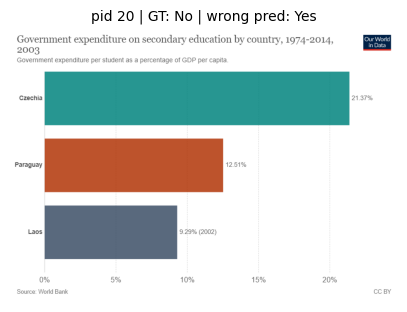

Q: Is the sum of smallest two bar is greater then the largest bar?

  [1_salient]
    The bar for Czechia is the longest, followed by Paraguay, and then Laos, which is the shortest.
  [2_subtle]
    The smallest bar represents Laos with a value of 9.29% (2002), the second smallest is Paraguay
    at 12.51%, and the largest is Czechia at 21.37%.
  [3_spatial]
    The bar for Laos is the shortest, followed by Paraguay, and then Czechia is the longest. The sum
    of the lengths of the bars for Laos and Paraguay appears to be less than the length of the bar
    for Czechia.
  [4_ocr]
    The bar for Czechia is labeled 21.37%, the bar for Paraguay is labeled 12.51%, and the bar for
    Laos is labeled 9.29% (2002).
  [5_distractor]
    The bar for Laos is labeled with "9.29% (2002)", which may mislead one to think it's a different
    year's data, potentially affecting the comparison if not carefully considered.
  [6_alternative]
    The bar for Laos is labeled with a value from 2002, whil

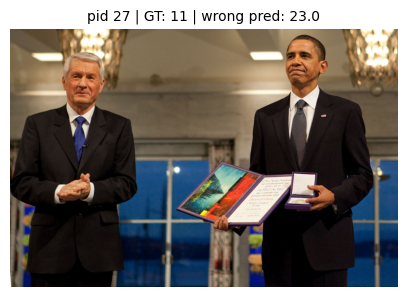

Q: What is the age gap between these two people in image?

  [1_salient]
    The image shows two men in formal attire, one holding a Nobel Prize certificate and medal, with
    visible differences in their physical appearance suggesting an age gap.
  [2_subtle]
    The man on the left has gray hair and appears older, while the man on the right has dark hair
    and appears younger.
  [3_spatial]
    The man on the left has gray hair and appears older, while the man on the right has dark hair
    and appears younger, suggesting a significant age difference between them.
  [4_ocr]
    The image shows two men in formal attire, one holding a certificate and medal, with no visible
    text or symbols indicating their ages or birth years.
  [5_distractor]
    The man on the left has gray hair and appears older, while the man on the right has dark hair
    and appears younger, suggesting a significant age difference.
  [6_alternative]
    The image shows two men in formal attire, one holding 

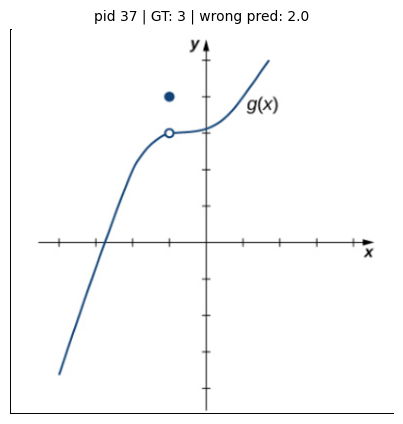

Q: What is the limit as x approaches -1?

  [1_salient]
    As x approaches -1 from both the left and right sides, the graph of g(x) approaches the same
    y-value, indicated by the open circle at approximately y = 2.
  [2_subtle]
    The graph shows a hole (open circle) at x = -1, indicating that the function is undefined at
    that point, but the curve approaches a specific y-value from both sides as x gets close to -1.
  [3_spatial]
    As x approaches -1 from both the left and right sides, the graph of g(x) approaches the same
    y-value, indicated by the open circle at approximately (-1, 2).
  [4_ocr]
    The graph shows a function g(x) with an open circle at x = -1, indicating the function is
    undefined there, and the curve approaches the same y-value from both sides as x gets close to
    -1.
  [5_distractor]
    The graph shows a hole at x = -1, indicating that g(-1) is undefined, but the function
    approaches the same y-value from both sides near x = -1.
  [6_alternati

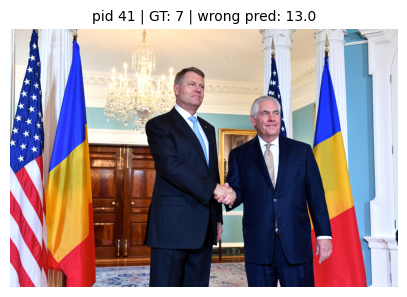

Q: What is the age gap between these two people in image?

  [1_salient]
    The man on the right has noticeably grayer hair and more visible facial lines compared to the
    man on the left, suggesting he is older.
  [2_subtle]
    The man on the right has noticeably grayer hair and more pronounced facial lines compared to the
    man on the left, suggesting he is older.
  [3_spatial]
    The man on the right has noticeably grayer hair and more visible facial lines compared to the
    man on the left, suggesting he is older.
  [4_ocr]
    The image shows two men in formal attire shaking hands, with flags of the United States and
    Romania in the background, but no visible text, numbers, or age indicators are present to
    determine their ages.
  [5_distractor]
    The man on the right has noticeably grayer hair and more pronounced facial lines compared to the
    man on the left, suggesting he is older.
  [6_alternative]
    The man on the right has noticeably grayer hair and more 

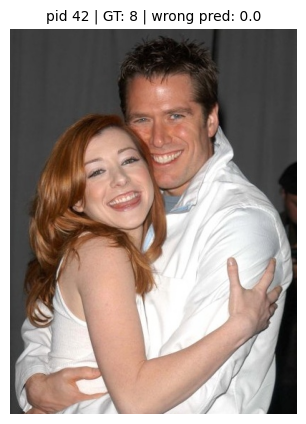

Q: What is the age gap between these two people in image?

  [1_salient]
    The man appears to be older than the woman, as indicated by differences in facial features and
    hairline.
  [2_subtle]
    The woman has long, flowing red hair and is wearing a white sleeveless top, while the man has
    short brown hair and is dressed in a white shirt with a blue collar visible underneath. Both
    individuals appear to be smiling warmly at the camera, suggesting a close relationship or event.
  [3_spatial]
    The man is positioned slightly behind and to the right of the woman, with his arm around her
    shoulder, suggesting a close physical relationship. The woman’s head is tilted toward him, and
    both are smiling directly at the camera, indicating a posed photograph likely taken at a public
    event or gathering.
  [4_ocr]
    The image shows two individuals embracing, with one appearing to be an adult male and the other
    an adult female, both smiling at the camera. No visible t

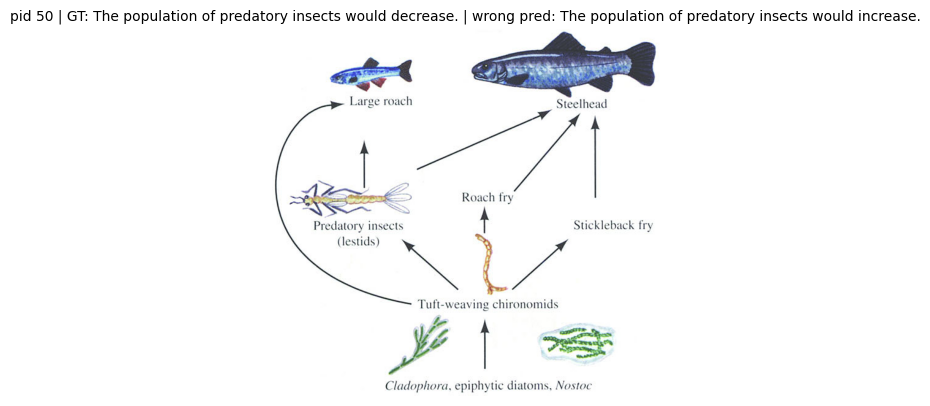

Q: Based on the food web, what would likely happen if the number of large roach would decrease?

  [1_salient]
    The diagram shows a direct arrow from "Predatory insects (lestids)" to "Large roach," indicating
    that predatory insects are a food source for large roach.
  [2_subtle]
    The arrow from predatory insects (lestids) points to large roach, indicating that large roach
    consume predatory insects.
  [3_spatial]
    The arrow from predatory insects (lestids) points to large roach, indicating that large roach
    consume predatory insects; therefore, a decrease in large roach would likely lead to an increase
    in the population of predatory insects due to reduced predation pressure.
  [4_ocr]
    The diagram shows an arrow pointing from "Predatory insects (lestids)" to "Large roach,"
    indicating that predatory insects are a food source for large roach.
  [5_distractor]
    The arrow from predatory insects (lestids) to large roach indicates that large roach consume
   

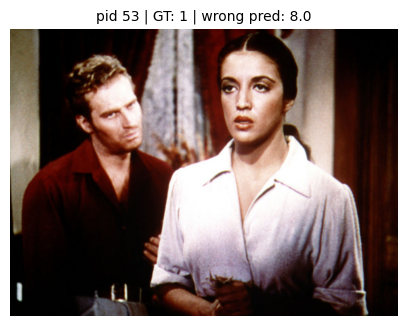

Q: What is the age gap between these two people in image?

  [1_salient]
    The man appears to have a more mature facial structure and slightly grayer hair compared to the
    woman, who has smoother skin and no visible signs of aging.
  [2_subtle]
    The man appears to have a more mature facial structure and slightly grayer hair compared to the
    woman, who has smoother skin and no visible signs of aging.
  [3_spatial]
    The man appears to be slightly older than the woman, based on his more mature facial features
    and hairstyle compared to her youthful appearance.
  [4_ocr]
    The image shows two individuals, a man and a woman, standing close together in what appears to
    be an indoor setting with curtains in the background. The man is wearing a dark red shirt and
    has short, light brown hair, while the woman is dressed in a white blouse with her dark hair
    pulled back. Both individuals appear to be adults, but their exact ages are not discernible from
    the image 

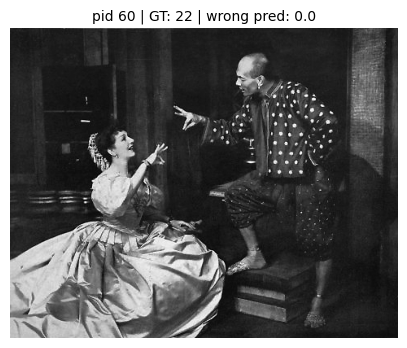

Q: What is the age gap between these two people in image?

  [1_salient]
    The woman appears to be in her 20s or 30s, while the man appears to be in his 50s or 60s,
    suggesting a significant age gap.
  [2_subtle]
    The man appears to have a receding hairline and more pronounced facial features, while the woman
    has youthful skin and styled hair, suggesting an age difference.
  [3_spatial]
    The man appears older with a receding hairline and more mature facial features, while the woman
    has youthful features and styled hair typical of a younger adult.
  [4_ocr]
    The image shows two individuals in period costumes, with one appearing to be an older man and
    the other a younger woman, engaged in a dramatic scene.
  [5_distractor]
    The man appears to be older than the woman, as indicated by his balding head and more mature
    facial features compared to her youthful appearance.
  [6_alternative]
    The woman appears to be in her late 20s or early 30s, while the man

In [7]:
import textwrap
import matplotlib.pyplot as plt

for r in all_records:
    img = Image.open(os.path.join(LOSS_DIR, f"pid_{r['pid']}", "image.png"))
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"pid {r['pid']} | GT: {r['ground_truth']} | wrong pred: {r['wrong_prediction']}", fontsize=10)
    plt.show()
    print(f"Q: {r['question']}\n")
    for mk in MODES:
        body = r["premises"][mk].replace("Visual premise:", "").strip()
        print(f"  [{mk}]")
        print(textwrap.fill(body, width=100, initial_indent="    ", subsequent_indent="    "))
    print("=" * 100)

## 8. Re-answering the loss cases with their premises

Surfacing a premise is diagnostic; the natural follow-up is *causal*: if we feed the
premises back to the model, do they fix the original wrong answer? We test two prompt
strategies, both of which keep the dataset's answer-format hint so the prediction stays
parseable by the original eval's `extract_pred` / `is_correct` (so **"correct" means the
same thing it did when the case was first mined as a loss**):

- **All-at-once** (`run_answer_with_premises.py` → `premise_answers/`): one prompt per case
  with all 9 premises listed together.
- **Per-premise** (`run_answer_per_premise.py` → `premise_answers_per_premise/`): 9 prompts
  per case, each carrying a **single** premise — 90 inferences total. This isolates each
  premise's effect and avoids cross-premise interference.

The cells below **load the saved results** (no GPU needed). Re-run the two standalone
scripts to regenerate them.

### 8a. How the premise-augmented prompt is built

Both scripts split the MathVista `query` (`"Hint: <format>\nQuestion: <q>"`) and reassemble
it with the premise(s) plus the answer-format hint. The only difference is one premise vs.
all nine.

In [ ]:
def split_query(query):
    """MathVista 'query' = 'Hint: <format>\nQuestion: <q>'. Split the two."""
    if "\nQuestion:" in query:
        hint, q = query.split("\nQuestion:", 1)
        return hint.strip(), q.strip()
    return "", query.strip()

def build_prompt_single(query, premise_text):
    """Per-premise: question + ONE premise (run_answer_per_premise.py)."""
    hint, question = split_query(query)
    premise_text = premise_text.replace("Visual premise:", "").strip()
    parts = [f"Question:\n{question}", "", f"Visual premise:\n{premise_text}", ""]
    if hint:
        parts.append(hint)
    parts += ["Now answer the question using the supported visual premise.",
              "Provide the final answer clearly."]
    return "\n".join(parts)

def build_prompt_all(query, premises):
    """All-at-once: question + all 9 premises (run_answer_with_premises.py)."""
    hint, question = split_query(query)
    block = "\n".join(f"{i}. {t.replace('Visual premise:', '').strip()}"
                       for i, (_m, t) in enumerate(premises.items(), 1))
    parts = [f"Question:\n{question}", "", f"Visual premises:\n{block}", ""]
    if hint:
        parts.append(hint)
    parts += ["Now answer the question using the supported visual premise.",
              "Provide the final answer clearly."]
    return "\n".join(parts)

# Example: the per-premise prompt actually sent for pid_27, mode 8_people
import json, os
_ex = json.load(open("premise_answers_per_premise/pid_27.json"))
print(_ex["per_premise"]["8_people"]["prompt"])

### 8b. Headline result

The all-at-once prompt fixes **0/10** cases. Feeding premises **one at a time** fixes
**2/10** — **1 genuine fix** (pid_27, from isolating the identity premises) plus 1 bad-label
artifact (pid_50); see §10. The `9_digits` mode currently fixes **0** cases, but pid_19 is an
instructive near-miss: the digit premise reads the markings correctly yet the model still
trusts the printed "600 ml" capacity label (§10).

In [ ]:
import json, glob, os

allatonce = json.load(open("premise_answers/summary.json"))
perprem   = json.load(open("premise_answers_per_premise/summary.json"))

print("all-at-once : fixed", allatonce["n_fixed"], "/ 10  ->", allatonce["fixed_pids"] or "none")
print("per-premise : fixed", perprem["n_cases_fixed_by_any"], "/ 10  ->", perprem["fixed_pids"])
print("\nper-mode correct counts (per-premise run):")
for m, c in perprem["per_mode_correct_counts"].items():
    print(f"  {m:<14} {c}")

## 9. The full answer matrix (mode × case)

For the per-premise run, every cell is the model's parsed answer when given **only** that
mode's premise; ✅ marks a match to ground truth. Reading across a row shows how sensitive a
case is to *which* premise it gets; reading down a column shows whether a mode is reliably
helpful.

In [ ]:
import json, glob, os

rows = sorted(glob.glob("premise_answers_per_premise/pid_*.json"),
              key=lambda p: int(os.path.basename(p)[4:-5]))
recs = [json.load(open(p)) for p in rows]
modes = list(recs[0]["per_premise"].keys())

# plain-text matrix (no pandas dependency): rows = modes, columns = cases
def cell(d):
    return ("OK " if d["correct"] else "   ") + str(d["prediction"])[:14]

W = 18
header = "mode".ljust(13) + "".join(f"pid_{r['pid']}".ljust(W) for r in recs)
print(header)
print("GT".ljust(13) + "".join(str(r["ground_truth"])[:14].ljust(W) for r in recs))
print("-" * len(header))
for m in modes:
    line = m.ljust(13) + "".join(cell(r["per_premise"][m]).ljust(W) for r in recs)
    print(line)
print("\n(OK = parsed answer matches ground truth)")

# locked-in vs premise-sensitive: how many distinct answers does each case give?
print("\ndistinct answers per case (1 = robust error, locked-in regardless of premise):")
for r in recs:
    preds = {r["per_premise"][m]["prediction"] for m in modes}
    print(f"  pid_{r['pid']:<3} -> {len(preds)} distinct"
          + ("   [locked-in]" if len(preds) == 1 else ""))

## 10. Findings

**1 genuine fix; one bad-label artifact; one instructive near-miss.**

- **✅ pid_27 (age gap, GT 11) — real fix from *isolating* premises.** One premise at a
  time let the model land the correct identities — Obama (1961) + Thorbjørn Jagland (1950)
  → **11**, correct on 5 of 9 modes. The *all-at-once* prompt got this **wrong** (it settled
  on Stoltenberg → 2): isolating premises removed the conflicting-identity confusion.
- **➖ pid_19 (beaker, "highest amount this class measures", GT 400) — near-miss / anchoring.**
  This case is **locked-in at 600**: all 9 modes answer 600. The `9_digits` premise *correctly*
  reads the graduations ("markings labeled 100, 200, 300, 400; highest marked value 400 ml"),
  yet the model still answers **600**, reasoning that the printed "600 ml" *capacity label* is
  the maximum — it anchors on the label over the graduations. (Earlier, a digit premise that
  explicitly called 400 the *"maximum measurable capacity"* did flip this to 400 — so the
  outcome is fragile and hinges on the premise asserting the *interpretation*, not just
  enumerating the digits.)
- **⚠️ pid_50 (food web, gold "decrease") — spurious fix.** A known **bad-label** case: gold
  says "decrease" but "increase" is correct. 8 of 9 premises correctly say *increase*; only
  the off-topic `8_people` premise (a food web has no people) derails the model into a
  truncated "decrease" that happens to match the wrong gold. The premise *degraded* the
  answer — it didn't fix it.

**Per-mode correct counts (9 modes):** `8_people`=2 (one spurious), `2_subtle` / `3_spatial`
/ `5_distractor` / `7_uncertainty`=1 each (all on pid_27), and `1_salient` / `4_ocr` /
`6_alternative` / `9_digits`=0.

**Behavioural patterns across the 10 cases:**

| pattern | cases | behaviour |
|---|---|---|
| **Locked-in errors** — every premise gives the *same* wrong answer | pid_7, 19, 20, 37 | premise has no effect; e.g. pid_19 stays 600 even when the premise reads the 400 marking correctly (anchors on the "600 ml" label) |
| **Premise-sensitive** — answer swings by mode | pid_27, 41, 42, 53, 60 | age-gap cases; the model guesses different identities/ages per premise |
| **Bad labels** | pid_20, pid_50 | model mostly holds its (correct) answer; "matching gold" means being *wrong* |

**Takeaway.** Isolating premises beats the all-at-once prompt (1 genuine fix vs 0), mainly by
removing cross-premise interference on the identity-guessing cases (pid_27). Targeting a
*specific* failure mode with a tailored premise (here `9_digits`) is promising but fragile:
on pid_19 the model reads the digits correctly and still anchors on the misleading capacity
label, and the fix only materialised under a phrasing that spelled out the *interpretation*.
Locked-in reasoning errors (pid_37's limit, pid_20's comparison) are untouched, and on
bad-label cases an off-topic premise can push a correct answer onto the wrong gold.